In [28]:
#loading Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("missing_context_analysis_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)


df = df.sort_values('date')
df.head()


,var3,var1,var5,var2,var4
date,,,,,
2018-01-01,8.4,92,33,0.09,0
2018-01-02,5.8,84,29,-0.12,0
2018-01-03,11.0,102,21,-0.09,0
2018-01-04,10.8,114,17,-0.25,0
2018-01-05,7.6,111,37,-0.04,0


In [27]:
df.describe()

,var3,var1,var5,var2,var4
count,2557.000000,2557.000000,2557.000000,2557.000000,2557.000000
mean,8.753109,86.349237,32.344153,-0.003625,0.021901
std,4.562154,36.286964,8.797210,0.370193,0.146388
min,0.000000,7.000000,2.000000,-0.730000,0.000000
25%,5.600000,70.000000,26.000000,-0.350000,0.000000
50%,9.000000,90.000000,32.000000,-0.010000,0.000000
75%,12.100000,113.000000,38.000000,0.340000,0.000000
max,22.600000,156.000000,59.000000,0.790000,1.000000


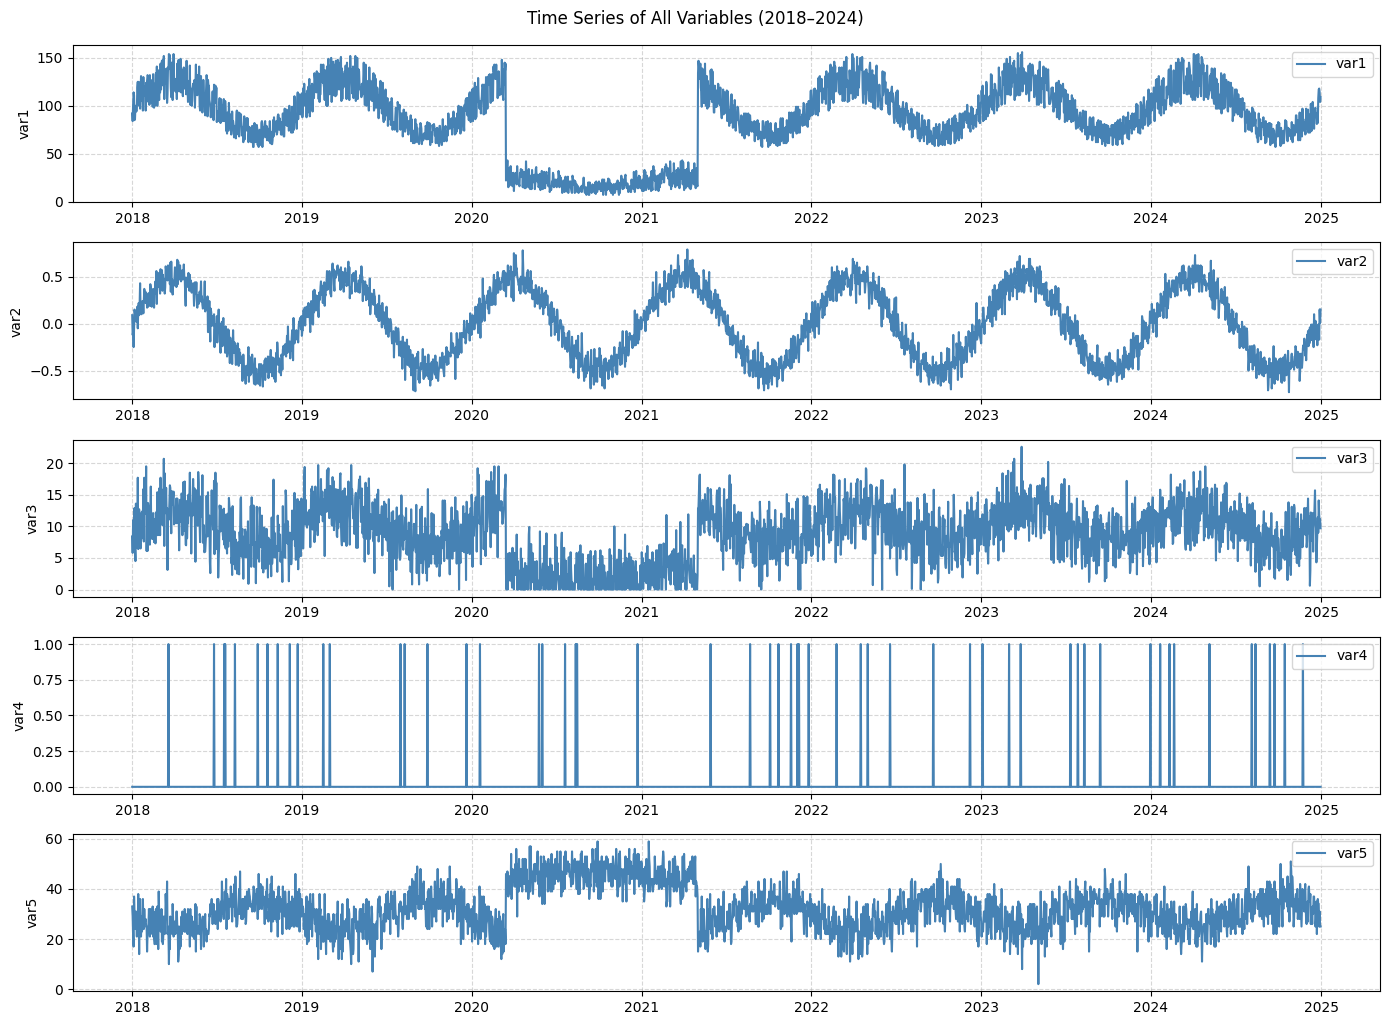

In [6]:
#Visualizing the data to see possible patterns

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 10))
for i, col in enumerate(['var1', 'var2', 'var3', 'var4', 'var5'], 1):
    plt.subplot(5, 1, i)
    plt.plot(df.index, df[col], label=col, color='steelblue')
    plt.ylabel(col)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(loc='upper right')
plt.tight_layout()
plt.suptitle("Time Series of All Variables (2018–2024)", y=1.02)
plt.show()

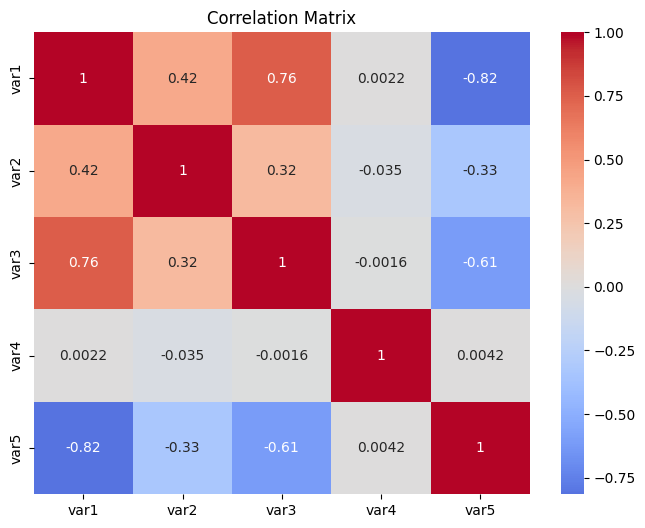

In [7]:
#checking for correlation
corr = df[['var1','var2','var3','var4','var5']].corr()

# Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title("Correlation Matrix")
plt.show()

In [22]:
# Anomaly Detection using Rolling Z-Score Method
import pandas as pd
import numpy as np

df = df.sort_index()

cols = ['var1', 'var3', 'var5']

rolling_mean = df[cols].rolling(window=30, min_periods=1).mean()
rolling_std = df[cols].rolling(window=30, min_periods=1).std()

rolling_std = rolling_std.replace(0, np.nan)

df_z = (df[cols] - rolling_mean) / rolling_std

df_z = df_z.replace([np.inf, -np.inf], np.nan)

anomalies = (df_z.abs() > 3).any(axis=1)


anomaly_dates = df[anomalies].index
first_six_anomalies = anomaly_dates[:6]

print("First major sx anomaly dates:")
for i, date in enumerate(first_six_anomalies, 1):
    print(f"{i}. {date.date()}")

First major sx anomaly dates:
1. 2019-07-08
2. 2020-03-15
3. 2020-03-16
4. 2020-11-03
5. 2021-02-23
6. 2021-05-02


In [29]:
# to Show which variables were anomalous on those dates
for date in first_six_anomalies:
    flagged_vars = df_z.loc[date][df_z.loc[date].abs() > 3].index.tolist()
    print(f"{date.date()}: anomalous in {', '.join(flagged_vars)}")

2019-07-08: anomalous in var3
2020-03-15: anomalous in var1, var5
2020-03-16: anomalous in var1
2020-11-03: anomalous in var3
2021-02-23: anomalous in var3
2021-05-02: anomalous in var1, var3, var5


In [20]:
# Checking the largest rises and drops in each variable
diff_df = df[['var1','var2','var3','var4','var5']].diff()
for col in diff_df.columns:
    drops = diff_df[col].nsmallest(10)
  
    print(f"\n{col} → Largest Drops:")
    for date, value in drops.items():
        print(f"  {date.date()}: {value}")


var1 → Largest Drops:
  2020-03-15: -122.0
  2019-04-27: -47.0
  2022-03-31: -47.0
  2019-03-06: -46.0
  2019-03-27: -46.0
  2018-03-11: -45.0
  2023-03-22: -44.0
  2019-05-01: -43.0
  2024-03-05: -43.0
  2023-02-21: -42.0

var2 → Largest Drops:
  2021-09-09: -0.48999999999999994
  2020-08-18: -0.44999999999999996
  2022-07-03: -0.42000000000000004
  2021-04-10: -0.4
  2019-08-11: -0.39999999999999997
  2022-12-23: -0.39
  2024-05-10: -0.39
  2018-06-13: -0.38
  2019-05-28: -0.38
  2021-05-27: -0.38

var3 → Largest Drops:
  2020-03-15: -15.799999999999999
  2019-07-08: -13.8
  2018-03-11: -13.799999999999999
  2018-02-01: -13.4
  2021-12-04: -12.8
  2018-11-02: -12.299999999999999
  2022-05-13: -12.200000000000001
  2019-07-15: -12.1
  2023-06-24: -12.0
  2021-07-10: -11.600000000000001

var4 → Largest Drops:
  2018-03-21: -1.0
  2018-06-27: -1.0
  2018-07-19: -1.0
  2018-07-21: -1.0
  2018-08-11: -1.0
  2018-09-29: -1.0
  2018-10-20: -1.0
  2018-11-11: -1.0
  2018-12-07: -1.0
  2018-

In [19]:
# Largest drops & rises per variable
diff_df = df[cols].diff()
for col in cols:
    print(f"\n{col} → Drops: {diff_df[col].nsmallest(10).index[0].date()}, Rises: {diff_df[col].nlargest(10).index[0].date()}")


var1 → Drops: 2020-03-15, Rises: 2021-05-02

var3 → Drops: 2020-03-15, Rises: 2022-06-03

var5 → Drops: 2019-06-02, Rises: 2020-03-15


In [30]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(contamination=0.02)
df['anomaly_score'] = clf.fit_predict(df[['var1','var2','var3','var4','var5']])

df[df['anomaly_score'] == -1]


,var3,var1,var5,var2,var4,anomaly_score
date,,,,,,
2018-03-20,11.0,138,22,0.47,1,-1
2018-06-26,17.2,122,30,0.10,1,-1
2018-07-18,7.1,84,33,-0.11,1,-1
2018-07-20,7.1,105,35,-0.31,1,-1
2018-09-28,5.0,59,28,-0.54,1,-1
2018-10-19,6.4,73,33,-0.49,1,-1
2018-11-10,11.7,89,21,-0.28,1,-1
2018-12-06,9.0,89,32,-0.19,1,-1
2018-12-23,14.3,114,29,-0.14,1,-1


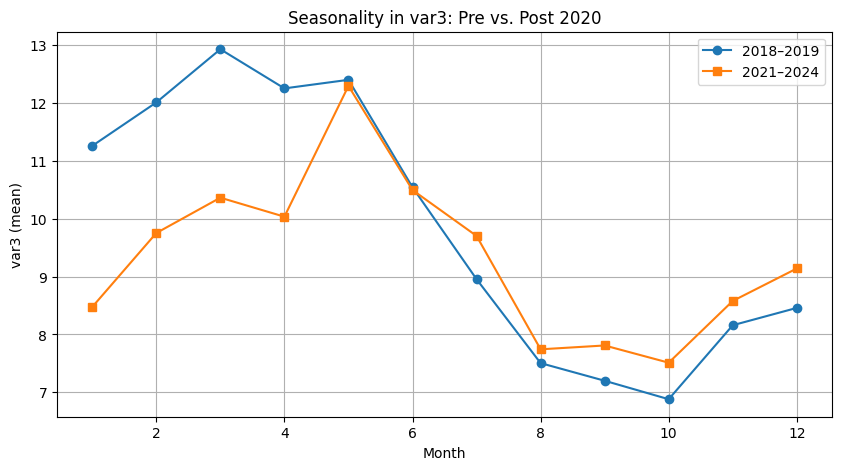

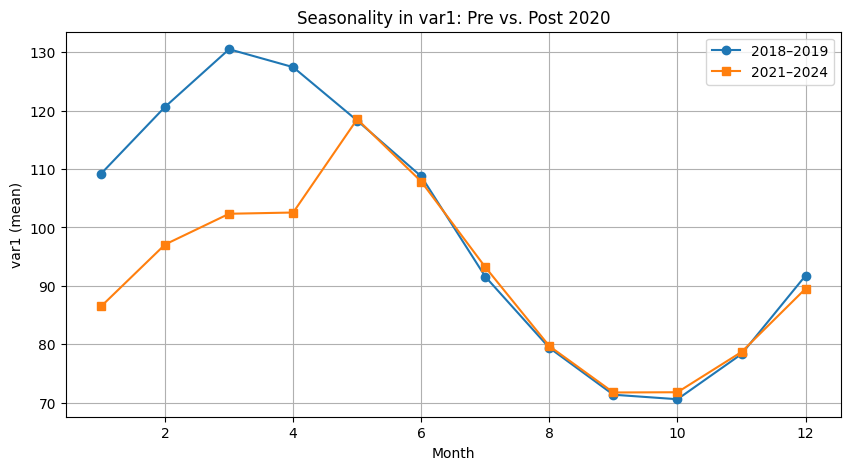

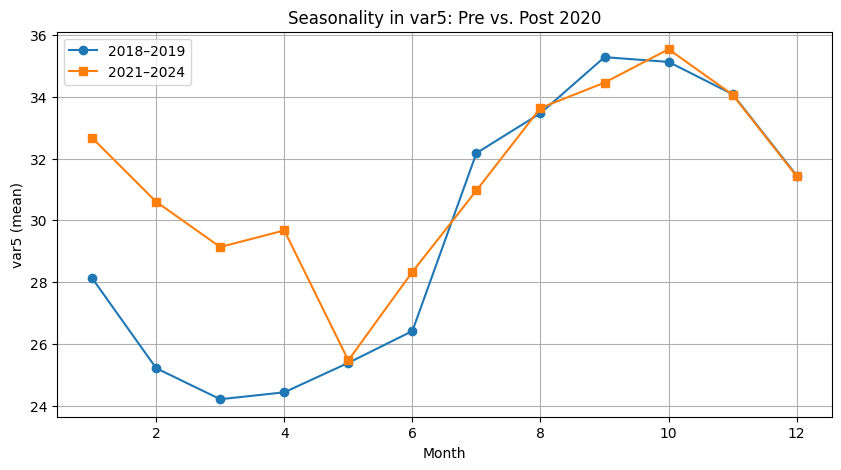

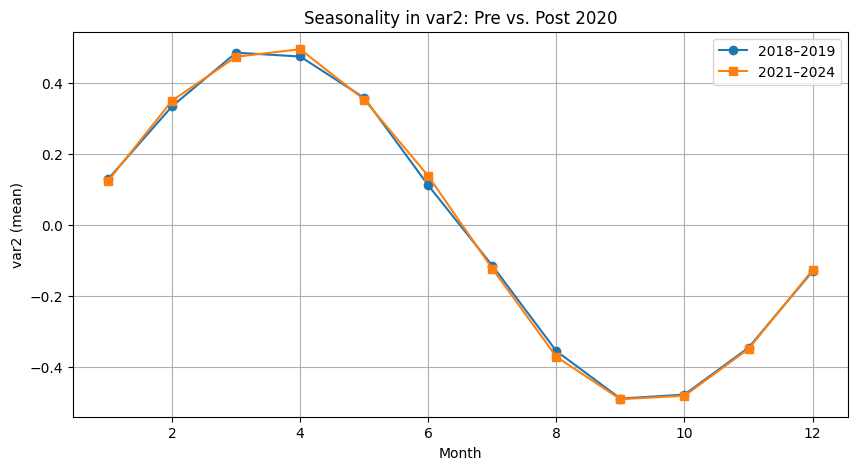

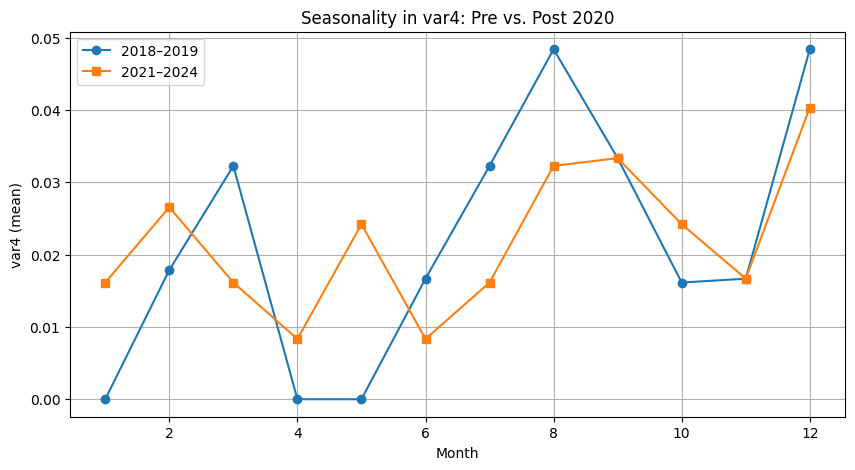

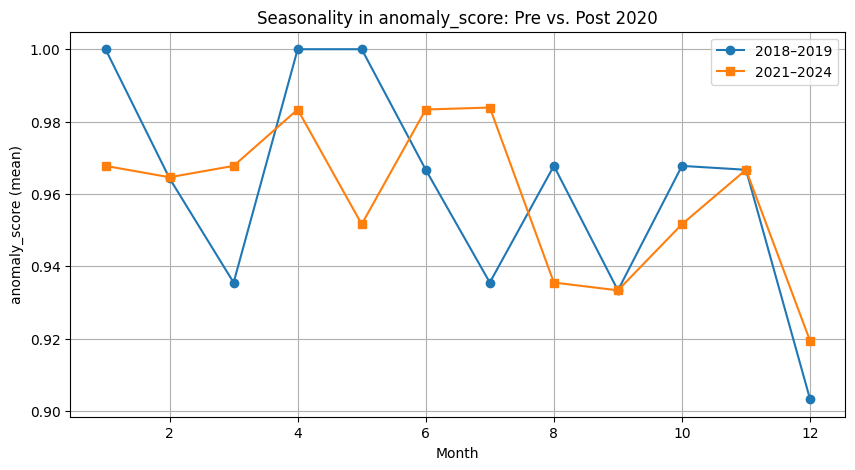

In [ ]:
# Split into pre-pandemic (2018–2019) and post-recovery (2021–2024)
pre = df['2018':'2019']
post = df['2021':'2024']

# Compare monthly patterns
pre_monthly = pre.groupby(pre.index.month).mean()
post_monthly = post.groupby(post.index.month).mean()

# List all variables (automatically detects them)
variables = df.columns

# Plot seasonality for each variable
for var in variables:
    plt.figure(figsize=(10,5))
    plt.plot(pre_monthly.index, pre_monthly[var], label='2018–2019', marker='o')
    plt.plot(post_monthly.index, post_monthly[var], label='2021–2024', marker='s')
    plt.xlabel('Month')
    plt.ylabel(f'{var} (mean)')
    plt.title(f'Seasonality in {var}: Pre vs. Post 2020')
    plt.legend()
    plt.grid(True)
    plt.show()


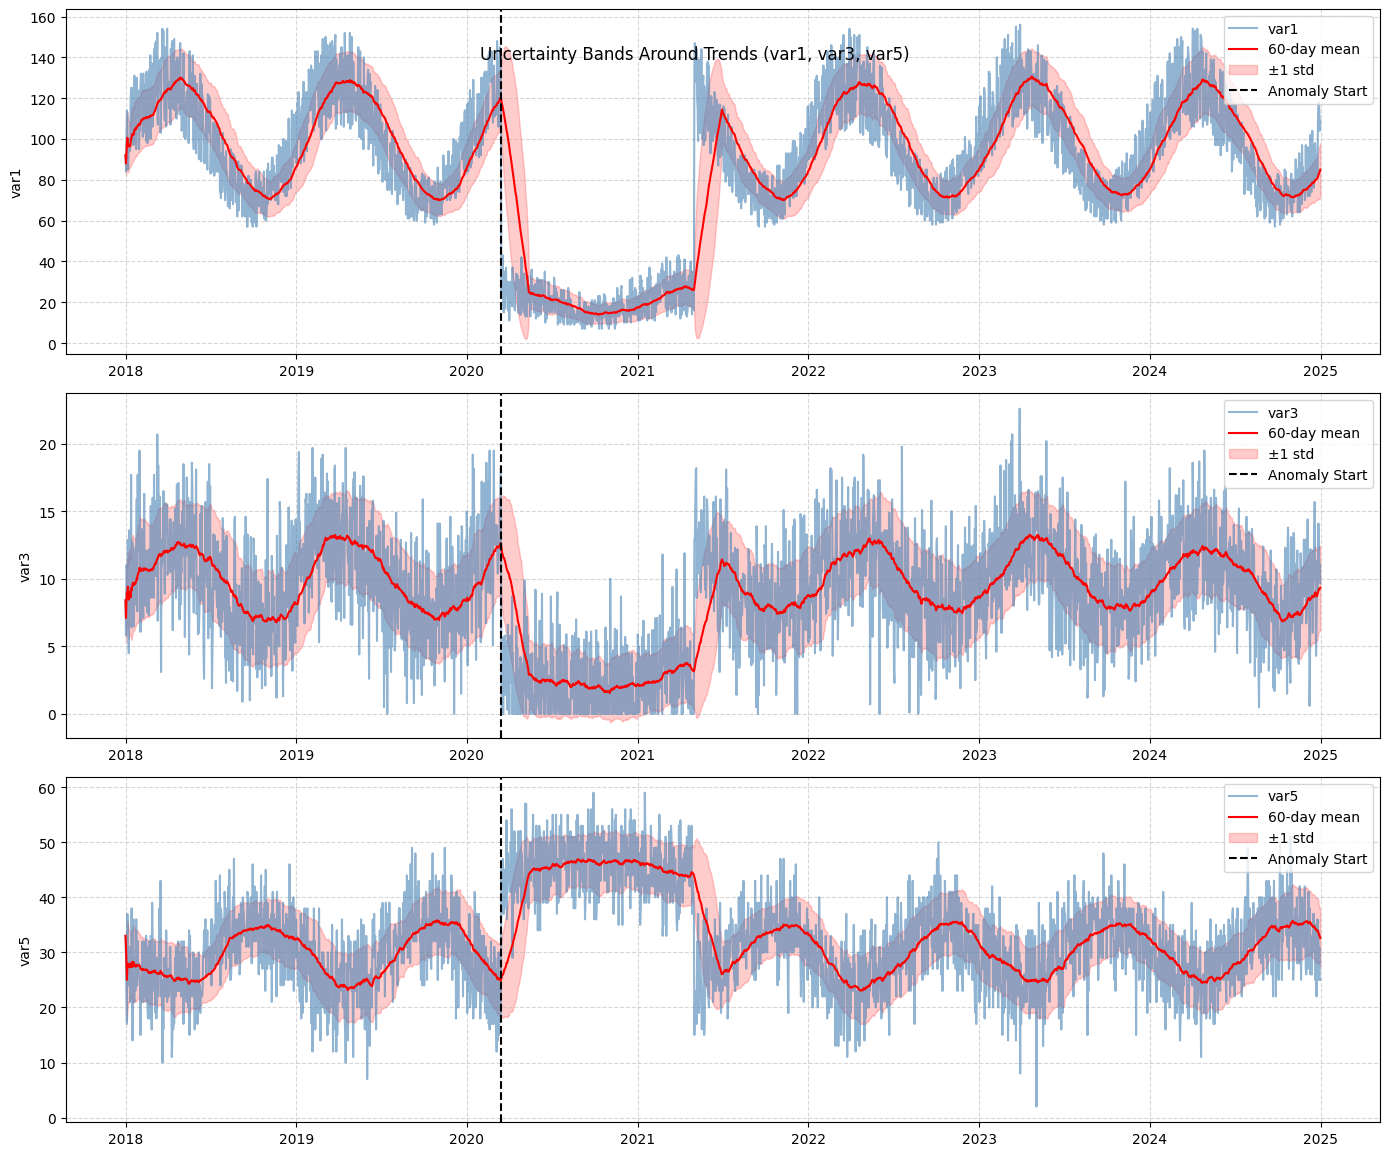

In [ ]:
# quantifying the uncertainty bands around trends
variables = ['var1', 'var3', 'var5']
window = 60  # Rolling window: 60 days

plt.figure(figsize=(14, 12))

for i, var in enumerate(variables, 1):
    # Compute rolling mean and std
    roll_mean = df[var].rolling(window=window, min_periods=1).mean()
    roll_std = df[var].rolling(window=window, min_periods=1).std()
    
    # Avoid division by zero in std (though unlikely here)
    roll_std = roll_std.replace(0, np.nan)
    
    # Plot
    plt.subplot(3, 1, i)
    plt.plot(df.index, df[var], alpha=0.6, label=var, color='steelblue')
    plt.plot(df.index, roll_mean, color='red', label=f'{window}-day mean')
    plt.fill_between(
        df.index,
        roll_mean - roll_std,
        roll_mean + roll_std,
        color='red',
        alpha=0.2,
        label='±1 std'
    )
    # Mark March 15, 2020 anomaly
    plt.axvline(pd.Timestamp('2020-03-15'), color='black', linestyle='--', label='Anomaly Start')
    
    plt.ylabel(var)
    plt.legend(loc='upper right')
    plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Uncertainty Bands Around Trends (var1, var3, var5)", y=0.93)
plt.tight_layout()
plt.show()